# UKF ハンズオン 2025.11.15

## 1. 準備

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# グラフのインライン表示設定
# %matplotlib inline 


## 2. 対象とする非線形システムと初期値の設定

以下の非常に簡単な非線形関数を考える

$ y=f(\theta )=\cos(\theta) $

そして、ある初期の確率分布（ガウス分布）を設定

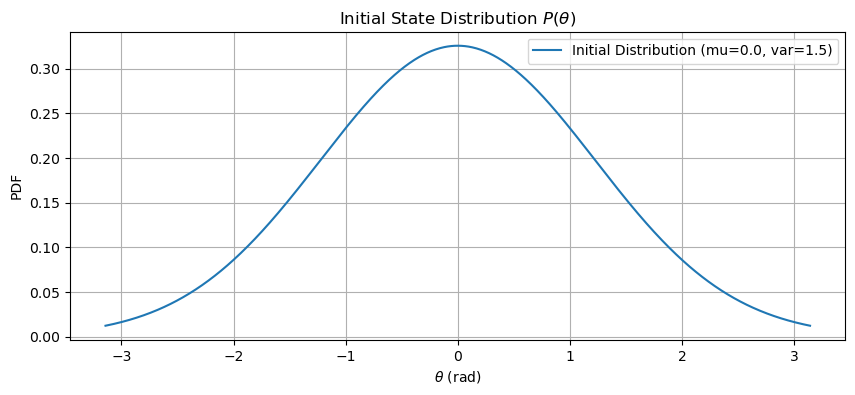

In [2]:
# 初期状態の平均と共分散 (角度 in radian)
mu_theta = 0.0 # 平均0ラジアン (真正面)
sigma_theta = 1.5 # 大きな分散

initial_distribution = multivariate_normal(mean=mu_theta, cov=sigma_theta)

# グラフ描画用に角度の範囲を定義 (-piからpiまで)
theta_range = np.linspace(-np.pi, np.pi, 1000)
pdf_theta = initial_distribution.pdf(theta_range)

# 非線形関数 f(theta) = cos(theta)
def nonlinear_function_cos(theta):
    return np.cos(theta)

# 結果の描画
plt.figure(figsize=(10, 4))
plt.plot(theta_range, pdf_theta, label=f'Initial Distribution (mu={mu_theta}, var={sigma_theta})')
plt.title('Initial State Distribution $P(\\theta)$')
plt.xlabel('$\\theta$ (rad)')
plt.ylabel('PDF')
plt.grid(True)
plt.legend()
plt.show()


## 3. EKFによる変換の実行（線形近似）

In [3]:
# EKFの計算
J = -np.sin(mu_theta) # ヤコビアン (df/d_theta at mu_theta)
mu_y_ekf = nonlinear_function_cos(mu_theta)
sigma_y_ekf = J * sigma_theta * J # 分散が0になる

print(f"EKF 変換後の平均 (y): {mu_y_ekf:.4f}")
print(f"EKF 変換後の分散 (y): {sigma_y_ekf:.4f}")


EKF 変換後の平均 (y): 1.0000
EKF 変換後の分散 (y): 0.0000


## 4. UKFによる変換の実行（Unscented Transform）

UKFは、シグマ点を使って変換します。今回は単純な1次元系なので、3つのシグマ点を使います。
1. シグマ点の生成
    - 重みパラメータ $\alpha $ や $\beta $ はデフォルト値（ここでは省略）を使用 
    - 代表的な3点は、$\mu -\sqrt{L+\lambda }\sigma $, $\mu $, $\mu +\sqrt{L+\lambda }\sigma $ となる。（$L$は次元数, $\lambda $はパラメータ）
1. シグマ点の非線形変換: 各点を $f(x)=x^{2}$ に通す
1. 変換後の平均・共分散の再計算: 変換された点の加重平均・加重共分散を計算

In [4]:
# UKFの計算 (正しいUT実装)

# パラメータ設定 (1次元 L=1)
L = 1
alpha = 1e-3
kappa = 0
beta = 2
lambda_ = alpha**2 * (L + kappa) - L

# 重みの計算
W_m = np.array([lambda_ / (L + lambda_), 1 / (2 * (L + lambda_)), 1 / (2 * (L + lambda_))])
W_c = np.array([lambda_ / (L + lambda_) + (1 - alpha**2 + beta), 1 / (2 * (L + lambda_)), 1 / (2 * (L + lambda_))])

# シグマ点の生成
sqrt_term = np.sqrt((L + lambda_) * sigma_theta)
# 3つのシグマ点 [mu, mu-sqrt_term, mu+sqrt_term]
X = np.array([mu_theta, mu_theta - sqrt_term, mu_theta + sqrt_term])

# シグマ点を非線形関数で変換
Y = nonlinear_function_cos(X)

# 変換後の平均と分散を再計算
mu_y_ukf = np.sum(W_m * Y)
sigma_y_ukf = np.sum(W_c * (Y - mu_y_ukf)**2)

print(f"UKF 変換後の平均 (y): {mu_y_ukf:.4f}")
print(f"UKF 変換後の分散 (y): {sigma_y_ukf:.4f}")


UKF 変換後の平均 (y): 0.2500
UKF 変換後の分散 (y): 1.1250


## 5. 結果の比較と視覚化

EKFとUKFの結果、そして理想的な「真の値」（モンテカルロシミュレーションで近似）を比較


真の値 (モンテカルロ) 平均 (y): 0.4714, 分散 (y): 0.3023


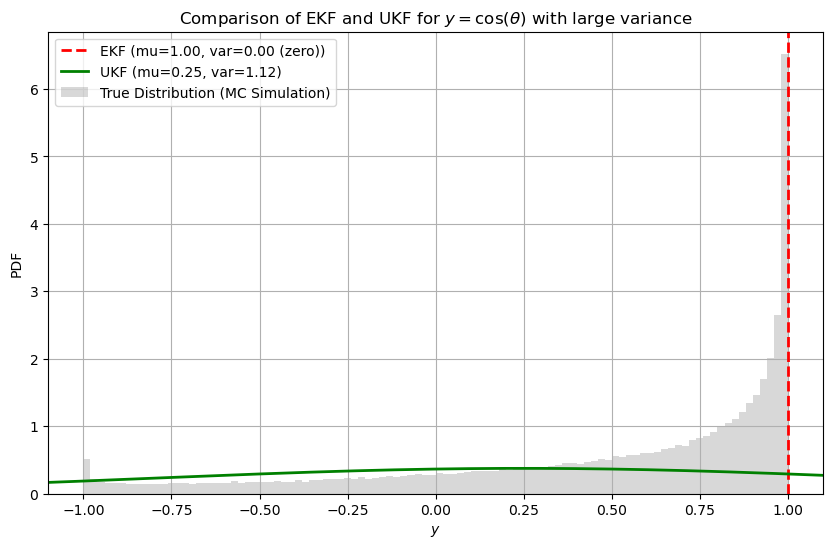

In [6]:
# 真の値の近似（モンテカルロシミュレーション）
np.random.seed(42)
samples = np.random.normal(mu_theta, np.sqrt(sigma_theta), 100000)
transformed_samples = nonlinear_function_cos(samples)
mu_y_true = np.mean(transformed_samples)
sigma_y_true = np.var(transformed_samples)

print(f"\n真の値 (モンテカルロ) 平均 (y): {mu_y_true:.4f}, 分散 (y): {sigma_y_true:.4f}")

# 結果の描画
plt.figure(figsize=(10, 6))
y_range = np.linspace(-1.2, 1.2, 1000)

# EKFの結果 (ガウス分布として描画) - 分散0なのでデルタ関数的に振る舞うが、ここでは分かりやすく線として描画
# EKFの結果は単なる点 (y=1.0, PDF無限大) に近い
# ここでは、EKFの平均位置に縦線を描画する
plt.axvline(x=mu_y_ekf, color='r', linestyle='--', label=f'EKF (mu={mu_y_ekf:.2f}, var={sigma_y_ekf:.2f} (zero))', linewidth=2)


# UKFの結果 (ガウス分布として描画)
pdf_y_ukf = multivariate_normal(mean=mu_y_ukf, cov=sigma_y_ukf).pdf(y_range)
plt.plot(y_range, pdf_y_ukf, 'g-', label=f'UKF (mu={mu_y_ukf:.2f}, var={sigma_y_ukf:.2f})', linewidth=2)

# 真の値のヒストグラム (モンテカルロ)
plt.hist(transformed_samples, bins=100, density=True, alpha=0.3, color='gray', label='True Distribution (MC Simulation)')

plt.title(r'Comparison of EKF and UKF for $y=\cos(\theta)$ with large variance')
plt.xlabel('$y$')
plt.ylabel('PDF')
plt.xlim(-1.1, 1.1)
plt.legend()
plt.grid(True)
plt.show()
